In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings
import sys
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(str(Path("../src").resolve()))

from config import Config
from dataloader import load_data_csv
from preprocessor import Preprocessor

warnings.simplefilter(action="ignore", category=FutureWarning)

config_path = Path("../config.toml").resolve()
config = Config.load(config_path)
df = load_data_csv(config)

preprocessor = Preprocessor(config)
df = preprocessor.run()
df

2025-03-29 11:17:23.108 | INFO     | dataloader:load_data_csv:36 - Data geladen met 9899 rijen.
2025-03-29 11:17:23.175 | INFO     | dataloader:load_data_csv:36 - Data geladen met 9899 rijen.
2025-03-29 11:17:23.199 | INFO     | preprocessor:clean_authors:27 - Authors opgeschoond.
2025-03-29 11:17:23.208 | INFO     | preprocessor:anonymize_authors:46 - 13 auteurs geanonimiseerd.
2025-03-29 11:17:23.218 | INFO     | preprocessor:add_message_length:51 - Kolom 'message_length' toegevoegd met lengte van elk bericht.
2025-03-29 11:17:23.237 | INFO     | preprocessor:add_author_info:57 - Auteur-info toegevoegd voor 13 auteurs.
2025-03-29 11:17:23.305 | INFO     | preprocessor:filter_automatic_messages:68 - 1534 automatische berichten verwijderd.
2025-03-29 11:17:23.341 | INFO     | preprocessor:filter_messages_after_september_2023:79 - 154 berichten vóór 1 september 2023 verwijderd.


,timestamp,author,message,message_length,age,gender,is_inlaw
196,2023-09-01 10:53:30,sprightly-rhinoceros,Wat we triestig weer zeg man man man\n,38,33.0,m,0.0
197,2023-09-01 10:56:11,snappy-ermine,Pff echt he\n,13,30.0,m,0.0
198,2023-09-01 10:56:39,decorated-shark,Duurt nog ff....pfffff 😢\n,26,55.0,f,0.0
199,2023-09-01 10:57:03,snappy-ermine,Na vandaag wel goed weer op komst lijkt 👌🏼\n,44,30.0,m,0.0
200,2023-09-01 10:58:44,decorated-shark,"Oh, gelukkig.\n",15,55.0,f,0.0
...,...,...,...,...,...,...,...
9893,2025-03-16 16:12:35,good-natured-ermine,Als ze aan zet echt niet normaal\n,34,25.0,f,0.0
9894,2025-03-16 17:16:14,crystalline-turkey,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",62,37.0,m,0.0
9895,2025-03-16 22:33:05,crystalline-turkey,"Wij zijn weer in Nederland, net de wieltjes w...",62,37.0,m,0.0
9896,2025-03-17 07:24:32,groovy-salmon,Welcome back! 💪🏻\n,18,35.0,m,0.0


In [15]:
# message length
import emoji


df['message_length'] = df['message'].astype(str).apply(len)

# has emoji
def count_emojis(text):
    return len([char for char in str(text) if char in emoji.EMOJI_DATA])

df['emoji_count'] = df['message'].apply(count_emojis)

# hour
df['hour'] = df['timestamp'].dt.hour

df


,timestamp,author,message,message_length,age,gender,is_inlaw,emoji_count,hour
196,2023-09-01 10:53:30,sprightly-rhinoceros,Wat we triestig weer zeg man man man\n,38,33.0,m,0.0,0,10
197,2023-09-01 10:56:11,snappy-ermine,Pff echt he\n,13,30.0,m,0.0,0,10
198,2023-09-01 10:56:39,decorated-shark,Duurt nog ff....pfffff 😢\n,26,55.0,f,0.0,1,10
199,2023-09-01 10:57:03,snappy-ermine,Na vandaag wel goed weer op komst lijkt 👌🏼\n,44,30.0,m,0.0,2,10
200,2023-09-01 10:58:44,decorated-shark,"Oh, gelukkig.\n",15,55.0,f,0.0,0,10
...,...,...,...,...,...,...,...,...,...
9893,2025-03-16 16:12:35,good-natured-ermine,Als ze aan zet echt niet normaal\n,34,25.0,f,0.0,0,16
9894,2025-03-16 17:16:14,crystalline-turkey,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",62,37.0,m,0.0,2,17
9895,2025-03-16 22:33:05,crystalline-turkey,"Wij zijn weer in Nederland, net de wieltjes w...",62,37.0,m,0.0,0,22
9896,2025-03-17 07:24:32,groovy-salmon,Welcome back! 💪🏻\n,18,35.0,m,0.0,2,7


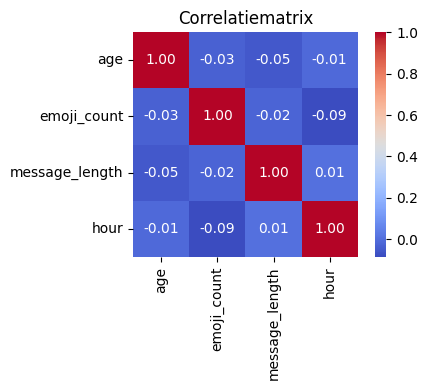

In [16]:
# find correlaties
corr = df[['age', 'emoji_count', 'message_length', 'hour']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlatiematrix')
plt.tight_layout()
plt.show()


De waardes zijn allemaal heel dicht bij nul (zoals -0.08 tot 0.01)

Er zijn geen sterke lineaire verbanden tussen de variabelen.

Leeftijd hangt niet duidelijk samen met emoji-gebruik of berichtlengte.

Emoji-gebruik varieert niet duidelijk per uur, enz.

Waarom die lage correlaties?
Je rekent per bericht, terwijl leeftijd en gender per persoon zijn.

Veel van de data is waarschijnlijk discreet of scheef verdeeld (bijv. veel korte berichtjes zonder emoji’s).

Er kunnen persoonlijke stijlverschillen zijn die pas opvallen als je per persoon aggregeert.

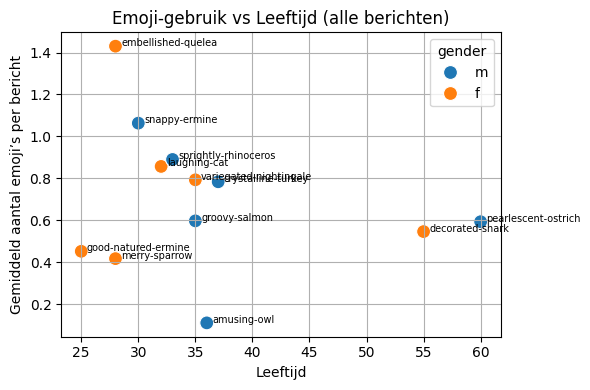

In [17]:
# Groepeer per bericht per persoon
emoji_df = df.groupby('author').agg({
    'emoji_count': 'mean',
    'age': 'first',
    'gender': 'first'
}).reset_index()

# Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=emoji_df, x='age', y='emoji_count', hue='gender', s=100)

for _, row in emoji_df.iterrows():
    plt.text(row['age'] + 0.5, row['emoji_count'], row['author'], fontsize=7)

plt.xlabel('Leeftijd')
plt.ylabel('Gemiddeld aantal emoji’s per bericht')
plt.title('Emoji-gebruik vs Leeftijd (alle berichten)')
plt.grid(True)
plt.tight_layout()
plt.show()

Jongeren (rond 28–32 jaar) lijken iets vaker emoji’s per bericht te gebruiken (tot bijna 0.9).

Er is géén duidelijke trend dat jong = meer emoji’s en oud = minder.

Één oudere persoon (rond 55) gebruikt relatief veel emoji’s

Maar de oudste (60) zit juist weer lager

Zowel mannen als vrouwen gebruiken emoji’s — dus gender is geen doorslaggevende factor

Conclusie:
Emoji-gebruik verschilt vooral per persoon, niet sterk per leeftijd of geslacht.

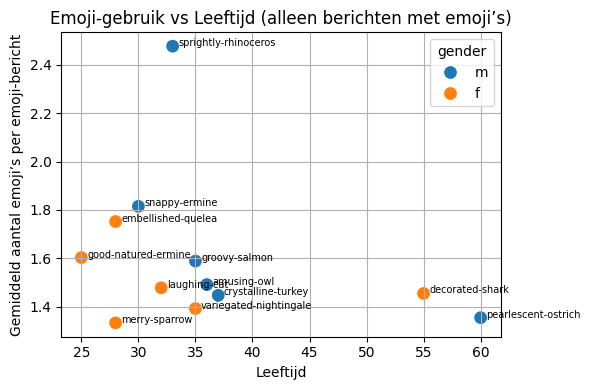

In [18]:
# Pak alleen data met emoji's (de vraag is of dit eerlijk is)
emoji_only_df = df[df['emoji_count'] > 0]

emoji_active_df = emoji_only_df.groupby('author').agg({
    'emoji_count': 'mean',
    'age': 'first',
    'gender': 'first'
}).reset_index()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=emoji_active_df, x='age', y='emoji_count', hue='gender', s=100)

for _, row in emoji_active_df.iterrows():
    plt.text(row['age'] + 0.5, row['emoji_count'], row['author'], fontsize=7)

plt.xlabel('Leeftijd')
plt.ylabel('Gemiddeld aantal emoji’s per emoji-bericht')
plt.title('Emoji-gebruik vs Leeftijd (alleen berichten met emoji’s)')
plt.grid(True)
plt.tight_layout()
plt.show()

De gemiddelde ligt hier tussen de 1.3 – 2.5 emoji’s per bericht

1 persoon stopt er wat meer in (rond de 2.5)

De 60-jarige gebruikt emoji’s, maar gemiddeld heel weinig per bericht

Vrouwen en mannen liggen redelijk verspreid

Conclusie:
Mensen die emoji’s gebruiken, doen dat gemiddeld vrij consistent — maar sommigen (ongeacht leeftijd) stoppen er veel meer in dan anderen.

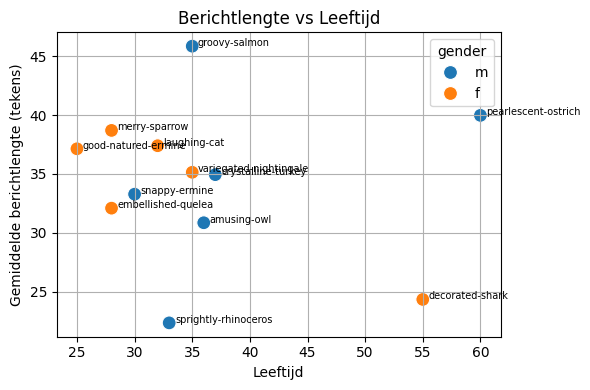

In [19]:
# kijk naar berichtlengte per persoon en leeftijd
length_df = df.groupby('author').agg({
    'message_length': 'mean',
    'age': 'first',
    'gender': 'first'
}).reset_index()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=length_df, x='age', y='message_length', hue='gender', s=100)

for _, row in length_df.iterrows():
    plt.text(row['age'] + 0.5, row['message_length'], row['author'], fontsize=7)

plt.xlabel('Leeftijd')
plt.ylabel('Gemiddelde berichtlengte (tekens)')
plt.title('Berichtlengte vs Leeftijd')
plt.grid(True)
plt.tight_layout()
plt.show()

Berichtlengtes liggen tussen ~23 en ~43 tekens

Er is géén duidelijke stijging of daling met leeftijd

De oudste (60) typt nog vrij lange berichten (~36 tekens)

Iemand van 55 typt juist opvallend kort (~24)

Jongeren (20–35) zitten overal: van kort tot lang

Conclusie:
Ook hier: berichtlengte is meer persoonsgebonden dan leeftijdsgebonden.

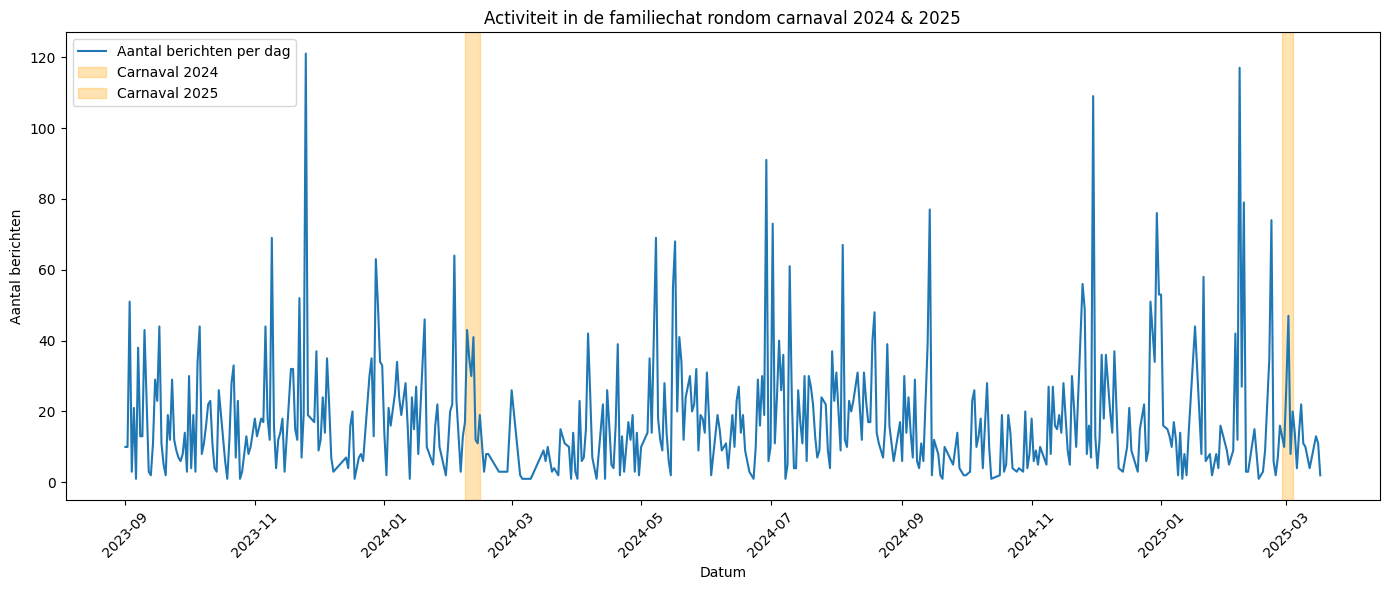

In [20]:
# Even over een andere boeg, Is er meer activiteit rondom carnaval?

# Zorg dat 'timestamp' en 'date' goed staan
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

# Filter op berichten vanaf 1 september 2023 (ik zit er pas sinds dien in)
start_date = pd.to_datetime('2023-09-01').date()
df_filtered = df[df['date'] >= start_date]

# Tel aantal berichten per dag
daily_counts = df_filtered.groupby('date').size().reset_index(name='message_count')

# Zet carnavalperiodes in een lijst [(start, end, label)]
carnavals = [
    (pd.to_datetime('2024-02-08').date(), pd.to_datetime('2024-02-15').date(), 'Carnaval 2024'),
    (pd.to_datetime('2025-02-27').date(), pd.to_datetime('2025-03-04').date(), 'Carnaval 2025')
]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(daily_counts['date'], daily_counts['message_count'], label='Aantal berichten per dag', color='tab:blue')

# Carnaval highlighten
for start, end, label in carnavals:
    plt.axvspan(start, end, color='orange', alpha=0.3, label=label)

# Zorg dat labels niet dubbel zijn in de legenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Datum')
plt.ylabel('Aantal berichten')
plt.title('Activiteit in de familiechat rondom carnaval 2024 & 2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Rond carnaval 2024 was er duidelijk verhoogde activiteit in de familiechat, wat mogelijk te maken heeft met het plannen of nabespreken van carnavalsactiviteiten. In 2025 lijkt de chat ook actiever, maar de piek is minder uitgesproken.

In [21]:
# Carnavalperiodes feature toevoegen
carnaval_2024 = (pd.to_datetime('2024-02-08'), pd.to_datetime('2024-02-15'))
carnaval_2025 = (pd.to_datetime('2025-02-27'), pd.to_datetime('2025-03-04'))

# Voeg carnaval feature toe
def is_carnaval(date):
    return (
        carnaval_2024[0].date() <= date <= carnaval_2024[1].date() or
        carnaval_2025[0].date() <= date <= carnaval_2025[1].date()
    )

df['is_carnaval'] = df['date'].apply(is_carnaval)
df

,timestamp,author,message,message_length,age,gender,is_inlaw,emoji_count,hour,date,is_carnaval
196,2023-09-01 10:53:30,sprightly-rhinoceros,Wat we triestig weer zeg man man man\n,38,33.0,m,0.0,0,10,2023-09-01,False
197,2023-09-01 10:56:11,snappy-ermine,Pff echt he\n,13,30.0,m,0.0,0,10,2023-09-01,False
198,2023-09-01 10:56:39,decorated-shark,Duurt nog ff....pfffff 😢\n,26,55.0,f,0.0,1,10,2023-09-01,False
199,2023-09-01 10:57:03,snappy-ermine,Na vandaag wel goed weer op komst lijkt 👌🏼\n,44,30.0,m,0.0,2,10,2023-09-01,False
200,2023-09-01 10:58:44,decorated-shark,"Oh, gelukkig.\n",15,55.0,f,0.0,0,10,2023-09-01,False
...,...,...,...,...,...,...,...,...,...,...,...
9893,2025-03-16 16:12:35,good-natured-ermine,Als ze aan zet echt niet normaal\n,34,25.0,f,0.0,0,16,2025-03-16,False
9894,2025-03-16 17:16:14,crystalline-turkey,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",62,37.0,m,0.0,2,17,2025-03-16,False
9895,2025-03-16 22:33:05,crystalline-turkey,"Wij zijn weer in Nederland, net de wieltjes w...",62,37.0,m,0.0,0,22,2025-03-16,False
9896,2025-03-17 07:24:32,groovy-salmon,Welcome back! 💪🏻\n,18,35.0,m,0.0,2,7,2025-03-17,False


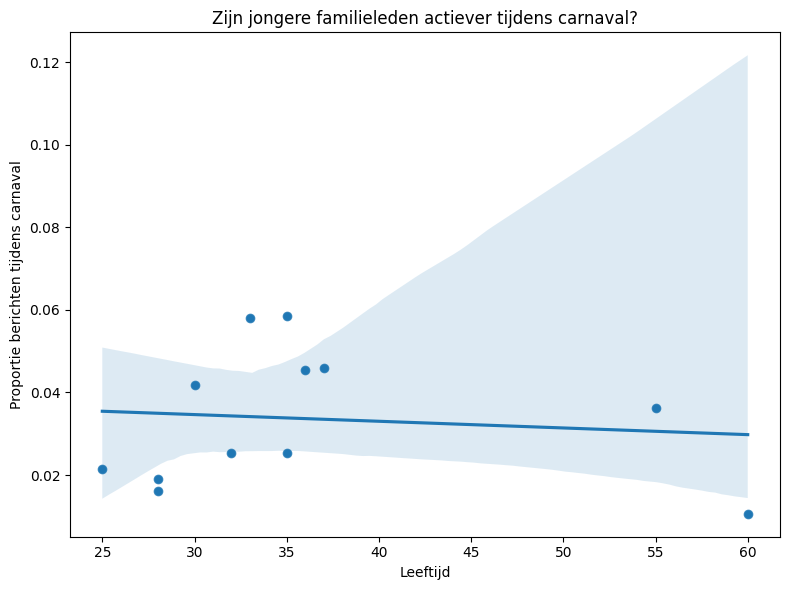

In [22]:
# Bereken aantal berichten per persoon tijdens carnaval en erbuiten
carnaval_counts = df.groupby(['author', 'is_carnaval']).size().unstack(fill_value=0)
carnaval_counts['age'] = df.groupby('author')['age'].first()
carnaval_counts['carnaval_ratio'] = carnaval_counts[True] / (carnaval_counts[True] + carnaval_counts[False])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=carnaval_counts, x='age', y='carnaval_ratio')
sns.regplot(data=carnaval_counts, x='age', y='carnaval_ratio')
plt.xlabel('Leeftijd')
plt.ylabel('Proportie berichten tijdens carnaval')
plt.title('Zijn jongere familieleden actiever tijdens carnaval?')
plt.tight_layout()
plt.show()


De scatterplot laat zien dat familieleden van rond de 35 jaar relatief het meest actief zijn tijdens carnaval: bij hen is ~6% van hun berichten in de carnavalsweek verstuurd. Zowel jongere als oudere familieleden lijken iets minder ‘aan’ te gaan tijdens carnaval. Dit kan duiden op een centrale rol van de 30–40-jarige generatie in het organiseren of beleven van het feest.

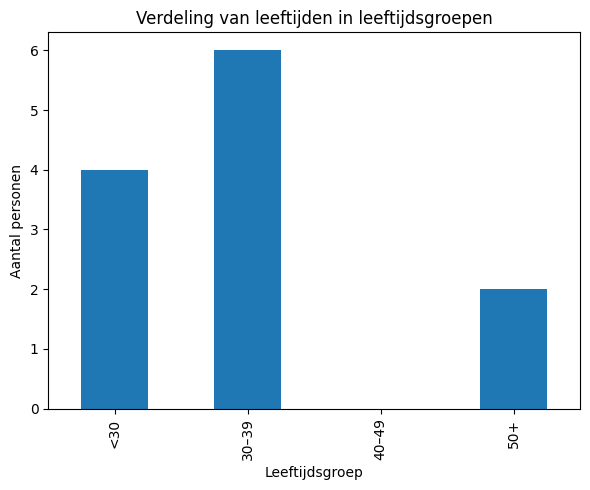

In [23]:
# Leeftijd per persoon
ages = df.groupby('author')['age'].first()

# Groepeer leeftijden in bins
bins = [0, 30, 40, 50, 100]
labels = ['<30', '30–39', '40–49', '50+']
age_groups = pd.cut(ages, bins=bins, labels=labels)

# Tel hoeveel personen in elke leeftijdsgroep zitten
age_group_counts = age_groups.value_counts().sort_index()


plt.figure(figsize=(6, 5))
age_group_counts.plot(kind='bar')
plt.xlabel('Leeftijdsgroep')
plt.ylabel('Aantal personen')
plt.title('Verdeling van leeftijden in leeftijdsgroepen')
plt.tight_layout()
plt.show()


De groep tussen 30 en 40 jaar is oververtegenwoordigd in de chat, waardoor het logisch is dat zij ook het meest actief lijken tijdens carnaval. De verhouding carnaval / totaal is daarom niet volledig onafhankelijk van groepssamenstelling.

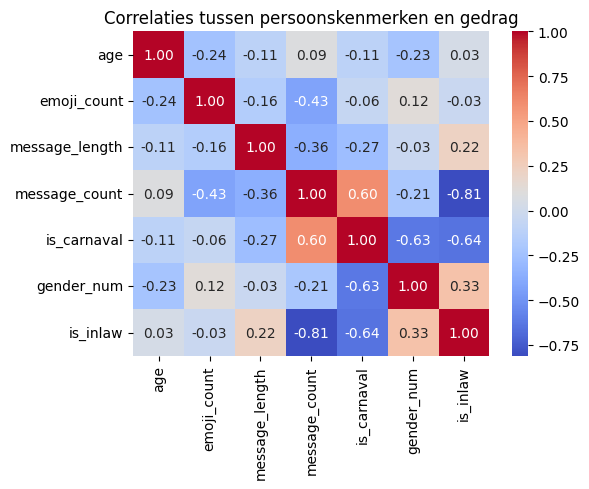

In [29]:
# nieuw DataFrame op persoonsniveau
person_df = df.groupby('author').agg({
    'emoji_count': 'mean',
    'message_length': 'mean',
    'age': 'first',
    'gender': 'first',
    'is_inlaw': 'first',
    'is_carnaval': 'mean',  # Hoeveel % van hun berichten zijn tijdens carnaval
    'timestamp': 'count'    # Aantal berichten 
}).rename(columns={'timestamp': 'message_count'}).reset_index()

# Haal NAN weg
person_df = person_df[person_df['gender'].notna()].copy()

# Zet gender om naar numeriek
person_df['gender_num'] = person_df['gender'].str.lower().map({'m': 0, 'f': 1})

# Alleen numerieke kolommen gebruiken
corr = person_df[['age', 'emoji_count', 'message_length', 'message_count', 'is_carnaval','gender_num','is_inlaw']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlaties tussen persoonskenmerken en gedrag")
plt.tight_layout()
plt.show()

## 🎭 Carnaval en gedrag

**Sterke negatieve correlatie tussen `is_inlaw` en `is_carnaval` (-0.64)**  
→ Aangetrouwde familieleden zijn veel minder actief tijdens carnaval.  
*Logisch als het een ‘carnavalsfamilie’ is en de ‘in-laws’ niet uit de regio komen of minder betrokken zijn.*

**Sterke negatieve correlatie tussen `gender_num` (vrouw = 1) en `is_carnaval` (-0.63)**  
→ Vrouwen zijn minder actief tijdens carnaval dan mannen.  
*Zou te maken kunnen hebben met dezelfde reden als hierboven: veel vrouwen zijn aangetrouwd.*

**Sterke positieve correlatie tussen `message_count` en `is_carnaval` (0.60)**  
→ Hoe meer iemand over het algemeen stuurt, hoe groter het aandeel tijdens carnaval.  
*Dus de meest actieve mensen zijn ook tijdens carnaval het meest aanwezig.*

---

## 🧑‍🤝‍🧑 Aangetrouwde familieleden (`is_inlaw`)

**Sterke negatieve correlatie met `message_count` (-0.81)**  
→ Aangetrouwden sturen over het algemeen véél minder berichten.  
*Ze zijn er wel bij, maar minder actief.*

**Negatieve correlatie met `message_length` (-0.22)**  
→ Ze sturen gemiddeld ook iets kortere berichten.

**Positieve correlatie met `gender_num` (0.33)**  
→ Aangetrouwden zijn vaker vrouw.


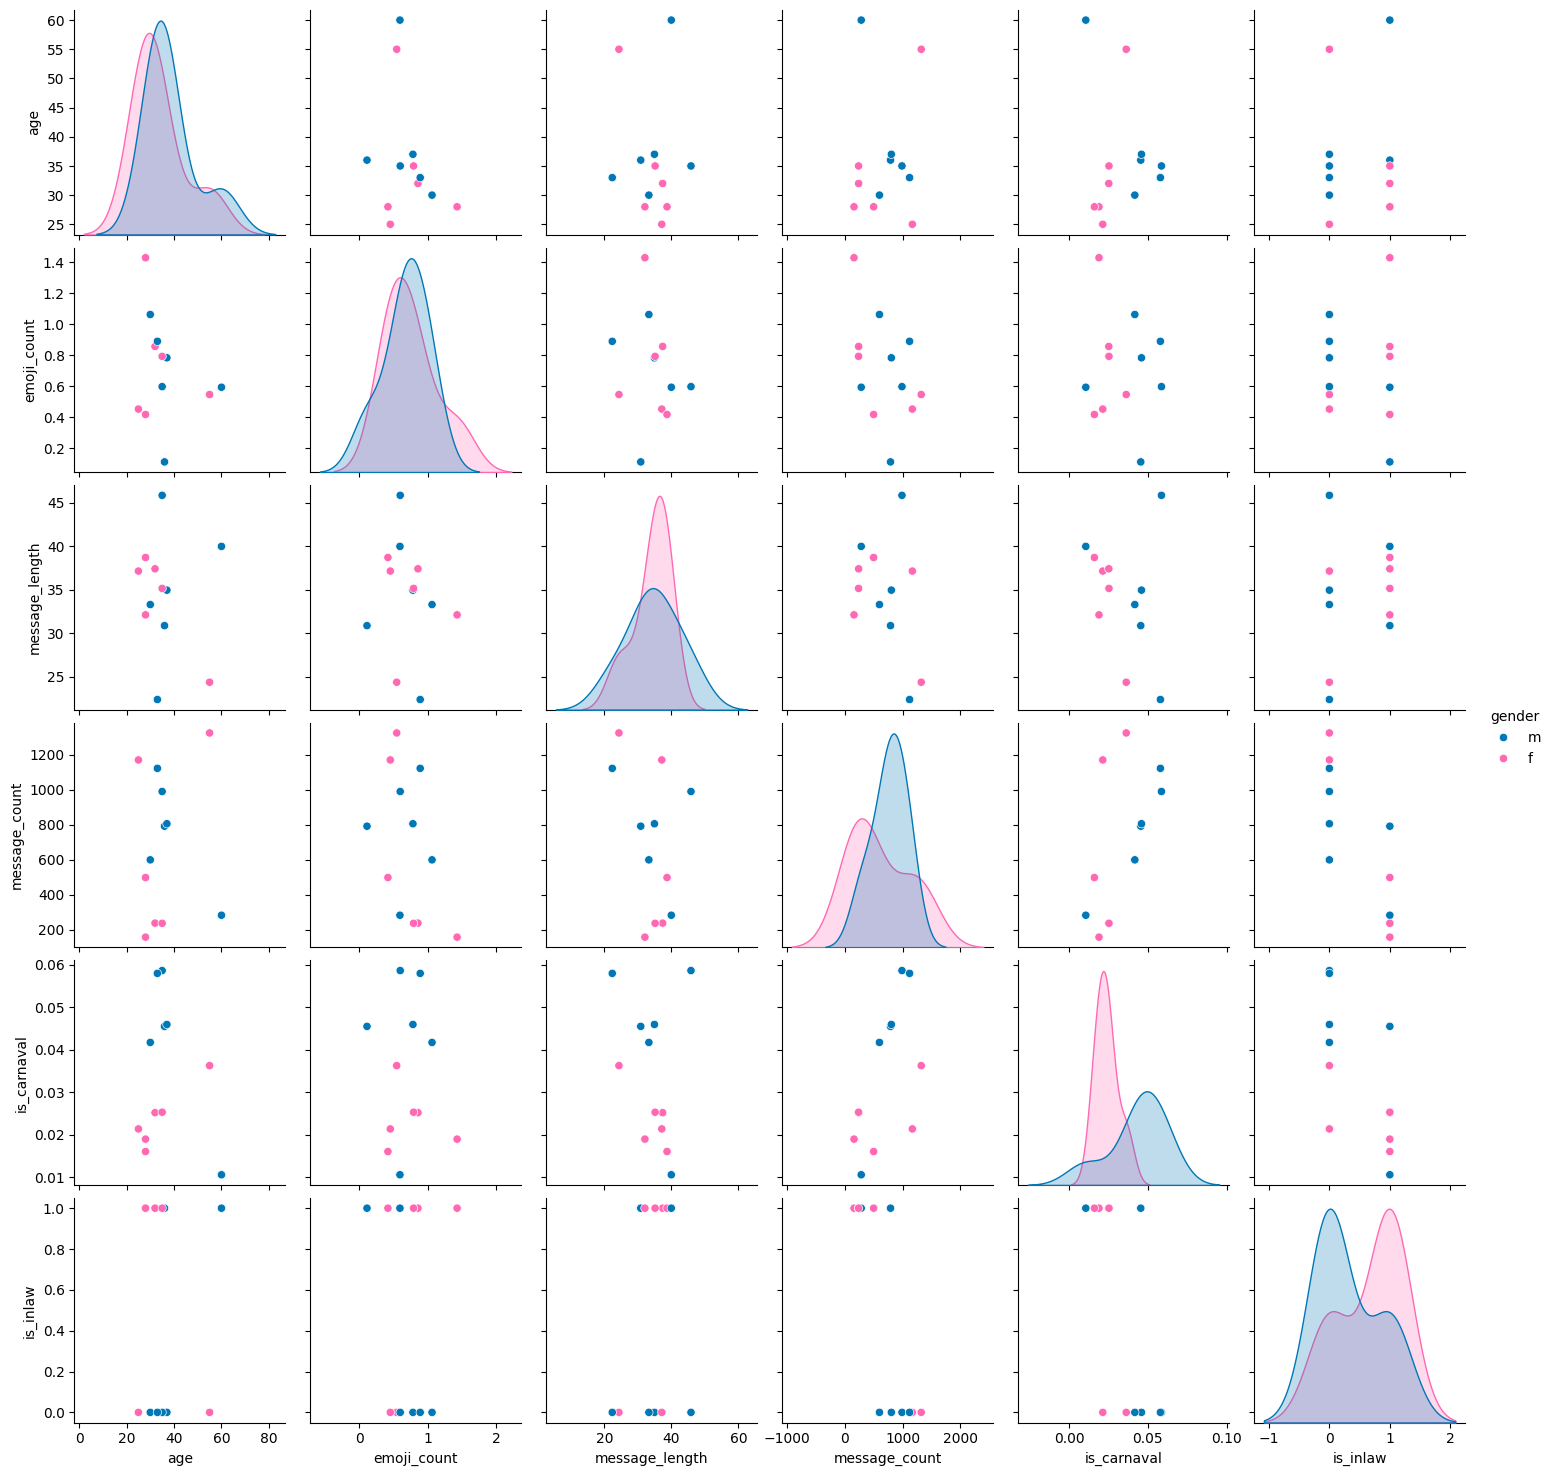

In [32]:
custom_palette = {'m': '#0077B6', 'f': '#FF69B4'}

sns.pairplot(person_df[['age', 'emoji_count', 'message_length', 'message_count', 'is_carnaval', 'gender','is_inlaw']], hue='gender', palette=custom_palette)


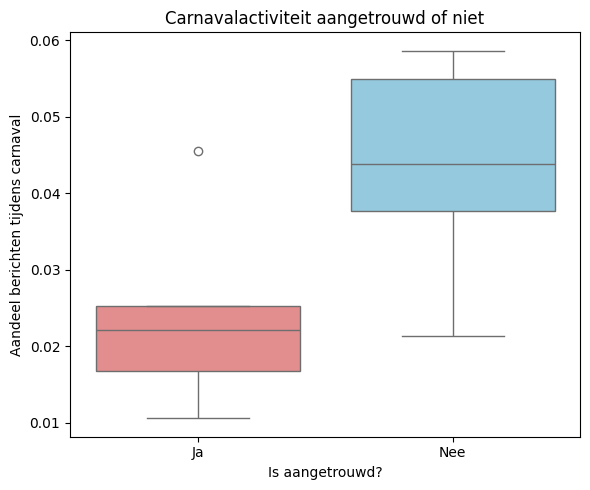

In [38]:
# Zijn niet aangetrouwde leden actiever tijdens carnaval?

# Zet 0/1 om naar 'Nee'/'Ja'
person_df['is_inlaw_label'] = person_df['is_inlaw'].map({0: 'Nee', 1: 'Ja'})

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=person_df,
    x='is_inlaw_label',
    y='is_carnaval',
    palette={"Nee": "skyblue", "Ja": "lightcoral"}
)
plt.xlabel('Is aangetrouwd?')
plt.ylabel('Aandeel berichten tijdens carnaval')
plt.title('Carnavalactiviteit aangetrouwd of niet')
plt.tight_layout()
plt.show()

## 🎭 Carnavalactiviteit: aangetrouwd of niet?

Uit de boxplot blijkt duidelijk dat **niet-aangetrouwde familieleden** een groter aandeel van hun berichten tijdens carnaval versturen dan aangetrouwde familieleden:

- Het **mediaan aandeel** berichten tijdens carnaval ligt bij niet-aangetrouwden rond de **0.045**, tegenover ongeveer **0.02–0.025** bij aangetrouwden.
- Niet-aangetrouwden tonen een grotere **spreiding**, wat erop wijst dat sommigen extreem actief zijn in deze periode.
- Aangetrouwden zijn gemiddeld duidelijk **minder betrokken** in de carnaval-chatactiviteit.

**Conclusie**: In deze typische carnavalsfamilie zijn het vooral de **kernleden (niet-aangetrouwden)** die de meeste activiteit vertonen tijdens carnaval. Aangetrouwden doen wel mee, maar lijken iets meer op de achtergrond te blijven.

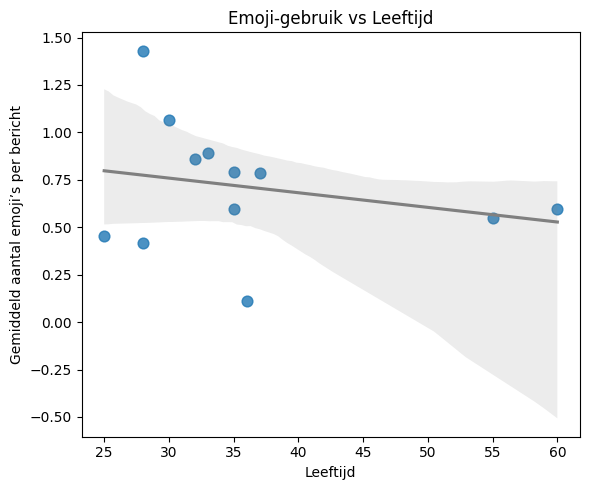

In [39]:
# Gebruiken jonge mensen ook meer emoji's? (correlatie = -0.24)
plt.figure(figsize=(6, 5))
sns.regplot(data=person_df, x='age', y='emoji_count', scatter_kws={'s': 60}, line_kws={'color': 'gray'})
plt.xlabel('Leeftijd')
plt.ylabel('Gemiddeld aantal emoji’s per bericht')
plt.title('Emoji-gebruik vs Leeftijd')
plt.tight_layout()
plt.show()


Negatieve trend: jongere mensen gebruiken gemiddeld meer emoji’s per bericht

Eén outlier met heel weinig emoji’s op leeftijd 35

Jongere familieleden maken gemiddeld vaker gebruik van emoji’s, al is de spreiding groot.

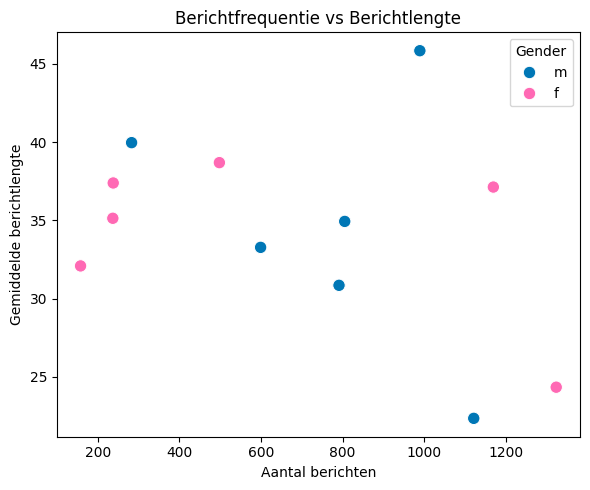

In [40]:
# Zijn mensen die veel praten ook de langste typers?
plt.figure(figsize=(6, 5))
sns.scatterplot(data=person_df, x='message_count', y='message_length', hue='gender', palette={'m': '#0077B6', 'f': '#FF69B4'}, s=80)
plt.xlabel('Aantal berichten')
plt.ylabel('Gemiddelde berichtlengte')
plt.title('Berichtfrequentie vs Berichtlengte')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

Mensen die heel veel berichten sturen, typen vaak korter

Vrouwen (roze) zitten vaak in het midden qua lengte & activiteit

Er lijkt een lichte inverse relatie te bestaan: wie veel berichten stuurt, houdt ze kort. Dit geldt iets meer voor mannen dan voor vrouwen. Maar niet perse een interessante relatie